In [49]:
!pip install keras-tuner

In [50]:
import tensorflow as tf
import kerastuner
import matplotlib.pyplot as plt
import numpy as np

In [51]:
tf.__version__

'2.15.0'

In [52]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [53]:
x_train.shape

(60000, 28, 28)

In [54]:
set(y_train)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

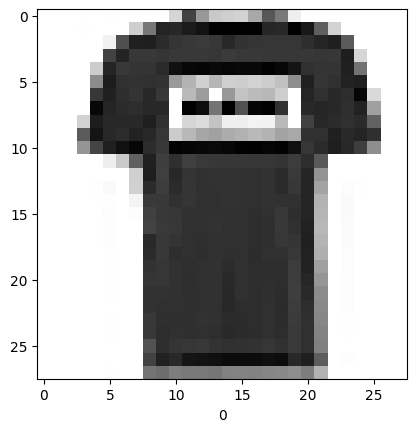

In [55]:
plt.imshow(x_train[1],cmap="binary")
plt.xlabel(y_train[1])
plt.show()

In [56]:
def create_model(hp):

  num_hidden_layers = 1
  num_units = 8
  dropout_rate = 0.1
  learning_rate = 0.01

  if hp:
    num_hidden_layers = hp.Choice('num_hidden_layers', values = [1,2,3])
    num_units = hp.Choice('num_units', values = [8,16,32])
    dropout_rate = hp.Float('dropout_rate', min_value = 0.1, max_value = 0.5)
    learning_rate = hp.Float('learning_rate', min_value = 0.0001, max_value = 0.01)

  model = tf.keras.models.Sequential()

  model.add(tf.keras.layers.Flatten(input_shape = (28,28)))
  model.add(tf.keras.layers.Lambda(lambda x: x/255.))

  for _ in range(0, num_hidden_layers):
    model.add(tf.keras.layers.Dense(num_units, activation='relu'))
    model.add(tf.keras.layers.Dropout(dropout_rate))

  model.add(tf.keras.layers.Dense(10, activation='softmax'))

  model.compile(
      loss='sparse_categorical_crossentropy',
      optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
      metrics=['accuracy']
  )

  return model

In [57]:
create_model(None).summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 lambda_1 (Lambda)           (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 8)                 6280      
                                                                 
 dropout_1 (Dropout)         (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 10)                90        
                                                                 
Total params: 6370 (24.88 KB)
Trainable params: 6370 (24.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [58]:
class CustomTuner(kerastuner.tuners.BayesianOptimization):
  def run_trial(self, trial, *args, **kwargs):
    kwargs['batch_size'] = trial.hyperparameters.Int('batch_size', 32, 128, step=32)
    results = super(CustomTuner, self).run_trial(trial, *args, **kwargs)
    return results

In [59]:
tuner = CustomTuner(
    create_model,
    objective='val_accuracy',
    max_trials=20,
    directory='logs',
    project_name='fashion_mnist',
    overwrite=True
)

In [60]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
num_hidden_layers (Choice)
{'default': 1, 'conditions': [], 'values': [1, 2, 3], 'ordered': True}
num_units (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': None, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'linear'}


In [61]:
tuner.search(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5, verbose=False
)

In [62]:
tuner.results_summary(1)

Results summary
Results in logs/fashion_mnist
Showing 1 best trials
Objective(name="val_accuracy", direction="max")

Trial 10 summary
Hyperparameters:
num_hidden_layers: 1
num_units: 32
dropout_rate: 0.19718738818657375
learning_rate: 0.007286221455255928
batch_size: 128
Score: 0.8495000004768372


In [63]:
model = tuner.get_best_models(num_models=1)[0]
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 lambda (Lambda)             (None, 784)               0         
                                                                 
 dense (Dense)               (None, 32)                25120     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                330       
                                                                 
Total params: 25450 (99.41 KB)
Trainable params: 25450 (99.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [66]:
_= model.fit(
    x_train,y_train,
    validation_data = (x_test,y_test),
    epochs=20, batch_size = 128,
    callbacks=(tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3))

)

Epoch 1/20
469/469 [==============================] - 4s 4ms/step - loss: 0.4785 - accuracy: 0.8231 - val_loss: 0.4267 - val_accuracy: 0.8473
Epoch 2/20
469/469 [==============================] - 1s 3ms/step - loss: 0.4684 - accuracy: 0.8276 - val_loss: 0.4167 - val_accuracy: 0.8470
Epoch 3/20
469/469 [==============================] - 2s 3ms/step - loss: 0.4564 - accuracy: 0.8332 - val_loss: 0.4350 - val_accuracy: 0.8478
Epoch 4/20
469/469 [==============================] - 1s 3ms/step - loss: 0.4526 - accuracy: 0.8322 - val_loss: 0.4145 - val_accuracy: 0.8489
Epoch 5/20
469/469 [==============================] - 1s 3ms/step - loss: 0.4485 - accuracy: 0.8333 - val_loss: 0.4189 - val_accuracy: 0.8515
Epoch 6/20
469/469 [==============================] - 1s 3ms/step - loss: 0.4469 - accuracy: 0.8332 - val_loss: 0.4188 - val_accuracy: 0.8481
Epoch 7/20
469/469 [==============================] - 2s 4ms/step - loss: 0.4406 - accuracy: 0.8360 - val_loss: 0.4329 - val_accuracy: 0.8437
Epoch 